In [ ]:
from datasets import load_dataset
import numpy as np

# one representative per modality you need
targets = {
    "images":     "legacysurvey",
    "spectra":    "sdss",
    "lightcurve": "plasticc",
    "xray":       "chandra",
}

def peek(name):
    dset = load_dataset(f"MultimodalUniverse/{name}", split="train", streaming=True)
    ex = next(iter(dset.with_format("numpy")))
    print(f"\n=== {name} ===")
    for k, v in ex.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s} array  shape={v.shape} dtype={v.dtype}")
        elif isinstance(v, dict):
            print(f"  {k:20s} dict   keys={list(v.keys())}")
        else:
            print(f"  {k:20s} {type(v).__name__:6s} {str(v)[:60]}")

for _, name in targets.items():
    peek(name)

In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

# --- 1. IMAGE: a literal photo of a patch of sky ---
img_dset = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)
img_ex = next(iter(img_dset.with_format("numpy")))

# --- 2. SPECTRUM: brightness split into a rainbow, plotted as a graph ---
spec_dset = load_dataset("MultimodalUniverse/sdss", split="train", streaming=True)
spec_ex = next(iter(spec_dset.with_format("numpy")))

# --- 3. LIGHT CURVE: brightness over time, plotted as a graph ---
lc_dset = load_dataset("MultimodalUniverse/plasticc", split="train", streaming=True)
lc_ex = next(iter(lc_dset.with_format("numpy")))

# --- Plot all three side by side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Image: just show it
axes[0].imshow(img_ex['rgb'])
axes[0].set_title(f"Image\nobject_id: {img_ex['object_id']}")
axes[0].axis('off')

# Spectrum: brightness vs wavelength
spec = spec_ex['spectrum']
axes[1].plot(spec['lambda'], spec['flux'], linewidth=0.7)
axes[1].set_title(f"Spectrum (z={spec_ex['Z']:.3f})")
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("Brightness")

# Light curve: brightness vs time, colored by filter/band
lc = lc_ex['lightcurve']
for b in np.unique(lc['band']):
    mask = lc['band'] == b
    axes[2].scatter(lc['time'][mask], lc['flux'][mask], s=12, label=str(b))
axes[2].set_title(f"Light curve\ntype: {lc_ex['obj_type']}")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Brightness")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
import lsdb
from lsdb.streams import CatalogStream

In [ ]:
gz10 = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_gz10")
sdss = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_sdss_sdss")

# So the line with compute essentially walks through every tile and does the full spatial join, handing us back a final pd/dask object (df)
# xmatch = gz10.crossmatch(sdss, n_neighbors=1).compute()
# This gets everything ready to stream as below
xmatch = gz10.crossmatch(sdss, n_neighbors=1)

In [ ]:
row = next(iter(CatalogStream(catalog=xmatch))).head(1).iloc[0]      

In [ ]:
open("g.png", "wb").write(row["rgb_image_mmu_gz10"]["bytes"]) 

In [ ]:
row

In [ ]:
import matplotlib.pyplot as plt
import io
from PIL import Image

# spectrum
s = row["spectrum_mmu_sdss_sdss"]
s = s[~s["mask"]]        # drop masked/bad pixels

lambd = s["lambda"]      # wavelength array
flux  = s["flux"]        # flux array
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# panel 1: the galaxy image, properly decoded (not just the raw pixelated write)
img_bytes = row["rgb_image_mmu_gz10"]["bytes"]
img = Image.open(io.BytesIO(img_bytes))
axes[0].imshow(img)
axes[0].set_title("GZ10 image")
axes[0].axis("off")

# panel 2: the spectrum
axes[1].plot(lambd, flux)
axes[1].set_xlabel("Wavelength (Å)")
axes[1].set_ylabel("Flux")
axes[1].set_title("SDSS spectrum")

plt.tight_layout()
plt.savefig("pair.png", dpi=150)
plt.show()

In [ ]:
# moving along the iterator!

stream_iter = iter(CatalogStream(catalog=xmatch))
rows = []
for _ in range(5):
    partition = next(stream_iter)
    rows.append(partition.head(1).iloc[0])

In [ ]:
# Contents of a spectra entry?
s

In [ ]:
import lsdb
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

# pull exactly 1 row
jwst = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_jwst_ceers")
sample = jwst.head(1)

row = next(sample.iterrows())[1]

In [ ]:
image_field = row['image']

In [ ]:
image_field

In [ ]:
one_flux = image_field["flux"].to_list()[0]   # the f090w row
print(type(one_flux))
print(type(one_flux[0]))
print(one_flux[0][:3] if hasattr(one_flux[0], "__getitem__") else one_flux[0])

In [ ]:
bands = [b.decode() if isinstance(b, (bytes, bytearray)) else str(b)
         for b in image_field["band"].tolist()]

flux = np.stack([np.stack(row).astype(np.float32) for row in image_field["flux"].to_list()])

print("object_id:", row["object_id"])
print("bands available:", bands)

band_name = "f090w"
i = bands.index(band_name)
img = flux[i]

norm = simple_norm(img, stretch="asinh", percent=99.75)

plt.figure(figsize=(4, 4))
plt.imshow(img, origin="lower", cmap="gray", norm=norm)
plt.title(f"{row['object_id']} — {band_name}")
plt.axis("off")
plt.show()

In [ ]:
# extract ivar and mask the same way we fixed for flux
ivar = np.stack([np.stack(r).astype(np.float32) for r in image_field["ivar"].to_list()])[i]
mask = np.stack([np.stack(r).astype(bool)  for r in image_field["mask"].to_list()])[i]

# signal-to-noise per pixel
snr = img * np.sqrt(np.clip(ivar, 0, None))   # clip guards against any stray negative ivar

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# flux (what you already have)
norm = simple_norm(img, stretch="asinh", percent=99.5)
axes[0].imshow(img, origin="lower", cmap="gray", norm=norm)
axes[0].set_title("flux")
axes[0].axis("off")

# snr — symmetric stretch since snr can be negative, centered so 0 = mid-gray
snr_norm = simple_norm(snr, stretch="asinh", percent=99.5)
axes[1].imshow(snr, origin="lower", cmap="coolwarm", norm=snr_norm)
axes[1].set_title(f"SNR (peak={snr.max():.1f})")
axes[1].axis("off")

# mask — binary, no stretch needed
axes[2].imshow(mask, origin="lower", cmap="gray_r")  # gray_r: True(bad)=dark or light depending on convention
axes[2].set_title("mask")
axes[2].axis("off")

plt.suptitle(f"{row['object_id']} — {band_name}")
plt.tight_layout()
plt.show()

print("fraction of pixels masked:", mask.mean())
print("peak SNR pixel is masked?:", mask[np.unravel_index(np.argmax(snr), snr.shape)])

In [ ]:
from dino_visualizer import visualize_attention_maps

visualize_attention_maps(
    'models/dinov2_vits14_pretrain.pth', 
    "climb holds good.v2i.sam2/train/2dsEiLjzMJpbtfyPj_jpg.rf.3b9e2bd5636268b9985b772a1e7f3a78.jpg", 
    num_registers=0, 
    view_mode="isolated", 
    mean=True,
    output_path='results/attention_map_without_registers'
)

In [ ]:
import lsdb

mmu_jwst_ceers = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_jwst_ceers")
other = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_desi_provabgs")

xm = mmu_jwst_ceers.crossmatch(other, radius_arcsec=1.0)
print(xm)


In [ ]:

# legacy_survey = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_ssl_legacysurvey_north")
# other = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_desi_provabgs")


In [ ]:



# legacy_survey = lsdb.open_catalog(
#     "hf://datasets/UniverseTBD/mmu_ssl_legacysurvey_north",
#     columns=["object_id", "ra", "dec", "image",
#              "flux_g", "flux_r", "flux_z", "ebv",
#              "psfdepth_g", "psfdepth_r", "psfdepth_z"],
# )

# other = lsdb.open_catalog(
#     "hf://datasets/UniverseTBD/mmu_desi_provabgs",
#     columns=["object_id", "ra", "dec",
#              "LOG_MSTAR", "Z_HP", "AVG_SFR", "TAGE_MW", "Z_MW"],
# )

# xmatch = legacy_survey.crossmatch(other, n_neighbors=1, radius_arcsec=0.1)

# got = []
# for chunk in CatalogStream(catalog=xmatch):
#     if len(chunk):
#         got.append(chunk)
#         if sum(len(c) for c in got) >= 250:
#             break

# rows = pd.concat(got).head(250)
# print(len(rows))

In [ ]:
print(rows.columns.tolist())
img0 = rows.iloc[0]["image_mmu_ssl_legacysurvey_north"]
print(img0["band"].tolist())
print(rows["_dist_arcsec"].describe())

In [ ]:
import lsdb
import pandas as pd
from lsdb.streams import CatalogStream

legacy_scalar = lsdb.open_catalog(
    "hf://datasets/UniverseTBD/mmu_ssl_legacysurvey_north",
    columns=["object_id", "ra", "dec"],
)
prov_scalar = lsdb.open_catalog(
    "hf://datasets/UniverseTBD/mmu_desi_provabgs",
    columns=["object_id", "ra", "dec", "LOG_MSTAR", "Z_HP", "AVG_SFR", "TAGE_MW", "Z_MW"],
)

xm = legacy_scalar.crossmatch(prov_scalar, radius_arcsec=0.1, n_neighbors=1)
matches = xm.compute()   # safe — no images, no MCMC chains
matches.to_parquet("legacy_provabgs_matches.parquet")
print(len(matches))

## The painful crossmatch of legacy_north with DESI_PROVABGS

In [32]:
import re, os
import numpy as np, pandas as pd
import pyarrow.parquet as pq
import lsdb
from lsdb.streams import CatalogStream
from huggingface_hub import HfApi, hf_hub_download

REPO = "UniverseTBD/mmu_ssl_legacysurvey_north"
BASE = "mmu_ssl_legacysurvey_north/dataset/"     # main catalog, NOT _10arcs
api  = HfApi()

legacy_scalar = lsdb.open_catalog(
    f"hf://datasets/{REPO}",
    columns=["object_id", "ra", "dec"],
)
prov_scalar = lsdb.open_catalog(
    "hf://datasets/UniverseTBD/mmu_desi_provabgs",
    columns=["object_id", "ra", "dec", "LOG_MSTAR", "Z_HP", "AVG_SFR", "TAGE_MW", "Z_MW"],
)

xm = legacy_scalar.crossmatch(prov_scalar, radius_arcsec=0.1, n_neighbors=1)

batch, n = [], 0
for chunk in CatalogStream(catalog=xm):
    if len(chunk):
        batch.append(chunk); n += len(chunk)
    if n >= 2000:
        break

matches = pd.concat(batch).head(2000).reset_index()
matches.to_parquet("sample_2k_matches_metadata.parquet")
print(len(matches), matches.columns.tolist())

/Users/gaurav/Desktop/Astrobridge/env/lib/python3.13/site-packages/lsdb/catalog/catalog.py:410: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


2000 ['_healpix_29', 'object_id_mmu_ssl_legacysurvey_north', 'ra_mmu_ssl_legacysurvey_north', 'dec_mmu_ssl_legacysurvey_north', 'object_id_mmu_desi_provabgs', 'ra_mmu_desi_provabgs', 'dec_mmu_desi_provabgs', 'LOG_MSTAR_mmu_desi_provabgs', 'Z_HP_mmu_desi_provabgs', 'AVG_SFR_mmu_desi_provabgs', 'TAGE_MW_mmu_desi_provabgs', 'Z_MW_mmu_desi_provabgs', '_dist_arcsec']


In [33]:
pixels = legacy_scalar.get_healpix_pixels()
orders = sorted({p.order for p in pixels})
known  = {(p.order, p.pixel) for p in pixels}

def partition_of(hp29):
    for o in orders:
        key = (o, hp29 >> (2 * (29 - o)))
        if key in known:
            return key

matches["_part"] = matches["_healpix_29"].map(partition_of)
assert matches["_part"].notna().all(), "some rows mapped to no partition"
print(matches.groupby("_part").size())

_part
(6, 9146)     559
(6, 11225)    327
(6, 11253)    581
(6, 11520)    431
(6, 11613)    102
dtype: int64


In [34]:
pat = re.compile(r"Norder=(\d+)/Dir=\d+/Npix=(\d+)\.parquet$")

path_by_pixel = {}
for f in api.list_repo_files(REPO, repo_type="dataset"):
    if not f.startswith(BASE):
        continue
    m = pat.search(f)
    if m:
        key = (int(m.group(1)), int(m.group(2)))
        assert key not in path_by_pixel, f"ambiguous: {f}"
        path_by_pixel[key] = f

info  = api.repo_info(REPO, repo_type="dataset", files_metadata=True)
sizes = {s.rfilename: s.size for s in info.siblings}

for part in matches["_part"].unique():
    p = path_by_pixel[part]
    assert "_10arcs" not in p
    print(part, p, round(sizes[p] / 1e9, 2), "GB")

(np.int64(6), np.int64(11225)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=11225.parquet 0.51 GB
(np.int64(6), np.int64(9146)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=0/Npix=9146.parquet 0.67 GB
(np.int64(6), np.int64(11253)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=11253.parquet 0.73 GB
(np.int64(6), np.int64(11613)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=11613.parquet 0.74 GB
(np.int64(6), np.int64(11520)) mmu_ssl_legacysurvey_north/dataset/Norder=6/Dir=10000/Npix=11520.parquet 0.68 GB


In [35]:
os.makedirs("cutouts", exist_ok=True)

# smallest file first, so failures surface cheaply
parts = sorted(matches["_part"].unique(), key=lambda p: sizes[path_by_pixel[p]])

for part in parts:
    wanted = set(matches.loc[matches["_part"] == part, "_healpix_29"])
    if all(os.path.exists(f"cutouts/{h}.npy") for h in wanted):
        print(part, "cached"); continue

    local = hf_hub_download(REPO, path_by_pixel[part],
                            repo_type="dataset", local_dir="hats_tmp")
    try:
        pf = pq.ParquetFile(local)
        for rg in range(pf.num_row_groups):
            idx = pf.read_row_group(rg, columns=["_healpix_29"])["_healpix_29"].to_pylist()
            hits = [i for i, h in enumerate(idx) if h in wanted]
            if not hits:
                continue
            imgs = pf.read_row_group(rg, columns=["image"])["image"].to_pylist()
            for i in hits:
                np.save(f"cutouts/{idx[i]}.npy", np.asarray(imgs[i]))
            del imgs
        del pf
    finally:
        os.remove(local)

    found = sum(1 for h in wanted if os.path.exists(f"cutouts/{h}.npy"))
    print(part, f"— {found}/{len(wanted)}")
    assert found > 0, f"{part}: matched no rows"

(np.int64(6), np.int64(11225)) — 327/327
(np.int64(6), np.int64(9146)) — 559/559
(np.int64(6), np.int64(11520)) — 431/431
(np.int64(6), np.int64(11253)) — 581/581
(np.int64(6), np.int64(11613)) — 102/102


In [40]:
meta = pd.read_parquet("sample_2k_matches_metadata.parquet").set_index("_healpix_29", drop=False)
obj = np.load(f"cutouts/{meta['_healpix_29'].iloc[0]}.npy", allow_pickle=True)
print("dtype:", obj.dtype, "shape:", obj.shape)

item = obj.item() if obj.shape == () else obj[0]
print("type:", type(item))
if isinstance(item, dict):
    for k, v in item.items():
        print(f"  {k}: {type(v).__name__}", np.shape(v))
else:
    print("len:", len(item), "first:", type(item[0]), np.shape(item[0]))

dtype: object shape: ()
type: <class 'dict'>
  band: list (3,)
  flux: list (3, 152, 152)
  psf_fwhm: list (3,)
  scale: list (3,)


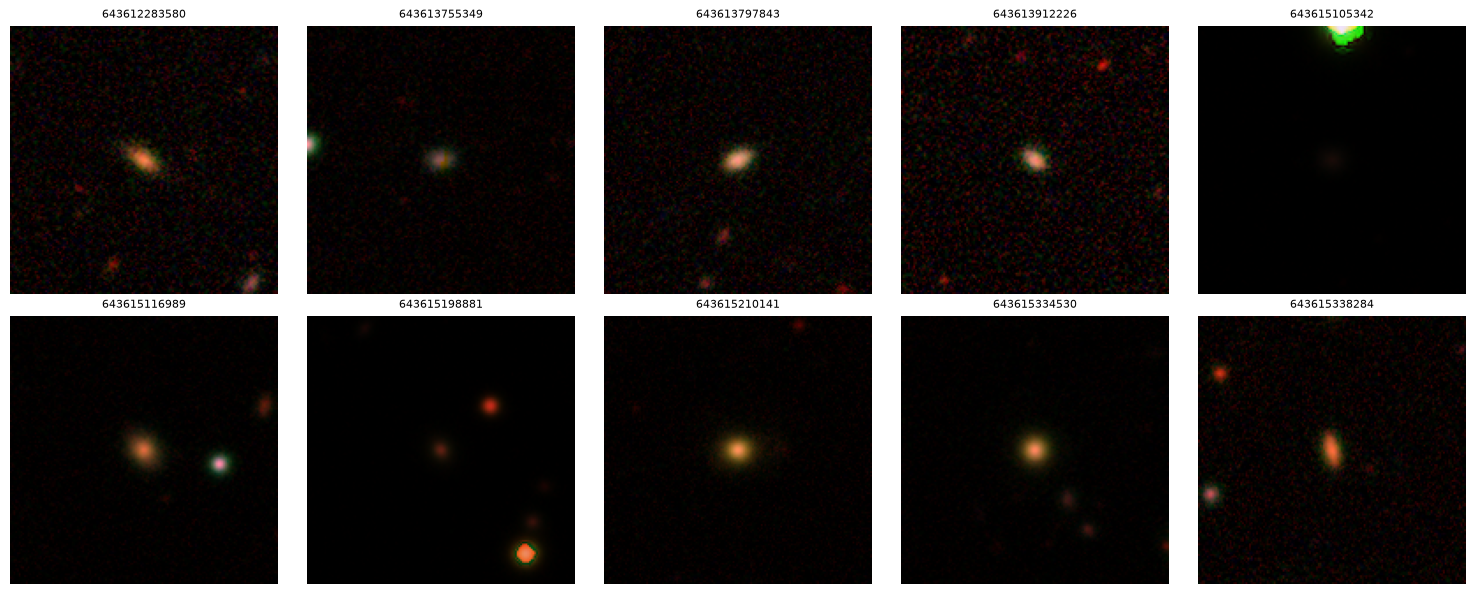

In [41]:
import glob
import numpy as np
import matplotlib.pyplot as plt

files = sorted(glob.glob("cutouts/*.npy"))[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, f in zip(axes.ravel(), files):
    g, r, z = np.asarray(np.load(f, allow_pickle=True).item()["flux"], dtype=np.float32)

    rgb = np.stack([z, r, g], axis=-1)
    rgb = np.arcsinh(rgb / np.percentile(rgb, 99.5))
    rgb = np.clip(rgb / rgb.max(), 0, 1)

    ax.imshow(rgb, origin="lower")
    ax.set_title(f.split("/")[-1][:12], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [42]:
import glob, json
import pandas as pd

meta = pd.read_parquet("sample_2k_matches_metadata.parquet")
meta["_healpix_29"] = meta["_healpix_29"].astype(str)

PROV_COLS = [
    "LOG_MSTAR_mmu_desi_provabgs",
    "Z_HP_mmu_desi_provabgs",
    "AVG_SFR_mmu_desi_provabgs",
    "TAGE_MW_mmu_desi_provabgs",
    "Z_MW_mmu_desi_provabgs",
]

files = sorted(glob.glob("cutouts/*.npy"))[:10]   # same slice as the plot
ids = [f.split("/")[-1].replace(".npy", "") for f in files]

sample = meta[meta["_healpix_29"].isin(ids)]

records = {}
for _, row in sample.iterrows():
    key = row["_healpix_29"]
    records[key] = {c.replace("_mmu_desi_provabgs", ""): row[c] for c in PROV_COLS}

with open("sample_10_labels.json", "w") as f:
    json.dump(records, f, indent=2)

print(records)

{'643615338284142486': {'LOG_MSTAR': 10.53271198272705, 'Z_HP': 0.19517579674720764, 'AVG_SFR': 0.5297374129295349, 'TAGE_MW': 9.693740844726562, 'Z_MW': 0.008888828568160534}, '643613912226410801': {'LOG_MSTAR': 10.875861167907715, 'Z_HP': 0.3521508574485779, 'AVG_SFR': 10.880078315734863, 'TAGE_MW': 6.90207576751709, 'Z_MW': 0.013671483844518661}, '643615210141042467': {'LOG_MSTAR': 11.052716255187988, 'Z_HP': 0.31899112462997437, 'AVG_SFR': 0.013601510785520077, 'TAGE_MW': 3.1830549240112305, 'Z_MW': 0.004878567066043615}, '643612283580683492': {'LOG_MSTAR': 10.642784118652344, 'Z_HP': 0.24145616590976715, 'AVG_SFR': 0.7720716595649719, 'TAGE_MW': 9.511521339416504, 'Z_MW': 0.003921651281416416}, '643615105342124693': {'LOG_MSTAR': 10.175690650939941, 'Z_HP': 0.18256230652332306, 'AVG_SFR': 0.7828779220581055, 'TAGE_MW': 5.993544101715088, 'Z_MW': 0.0017757487948983908}, '643613755349947095': {'LOG_MSTAR': 8.871760368347168, 'Z_HP': 0.07914071530103683, 'AVG_SFR': 0.1647676676511764

In [43]:
# ruff: noqa
# Configuring astropt for inference (95m param model)
import glob
from astropt.model_utils import load_astropt
from astropt.local_datasets import GalaxyImageDataset
import torch
import numpy as np
from torchvision import transforms

def normalise(x):
    std, mean = torch.std_mean(x, dim=1, keepdim=True)
    return (x - mean) / (std + 1e-8)

def data_transforms():
    return transforms.Compose([transforms.Lambda(normalise)])

model = load_astropt("Smith42/astroPT_v2.0", path="astropt/095M")

galproc = GalaxyImageDataset(
    None,
    spiral=True,
    transform={"images": data_transforms()},
    modality_registry=model.modality_registry
)

number of parameters: 95.18M
model loaded successfully from Smith42/astroPT_v2.0/astropt/095M
args: {'n_layer': 12, 'n_head': 12, 'n_embd': 768, 'n_chan': 3, 'block_size': 1024, 'dropout': 0.0, 'modalities': [ModalityConfig(name='images', input_size=768, pos_input_size=1, patch_size=16, embed_pos=True, loss_weight=1.0)], 'attn_type': 'causal'}


In [44]:

f = sorted(glob.glob("cutouts/*.npy"))[0]
g, r, z = np.asarray(np.load(f, allow_pickle=True).item()["flux"], dtype=np.float32)
img = np.stack([g, r, z], axis=-1)  # (H, W, C)

# pad 4 px on each side → e.g. 152x152 becomes 160x160, divisible by patch size 16
img = np.pad(img, ((4, 4), (4, 4), (0, 0)), mode="reflect")

galaxy = galproc.process_galaxy(
    torch.from_numpy(img.swapaxes(0, 2)).to(float)
).to(torch.float)
galaxy_positions = torch.arange(0, len(galaxy), dtype=torch.long)

batch = {
    "images": galaxy.unsqueeze(0),           # add batch dim of 1
    "images_positions": galaxy_positions.unsqueeze(0),
}

with torch.no_grad():
    embedding = model.generate_embeddings(batch)["images"].detach().numpy()

print(embedding.shape)

(1, 768)
